In [59]:
import pandas as P
import seaborn as S
import numpy as N
import matplotlib.pyplot as MAT
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [60]:
Data_Iris = P.read_csv('/content/iris.csv')

In [61]:
display(Data_Iris)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [62]:
Data_Iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [63]:
Data_Iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


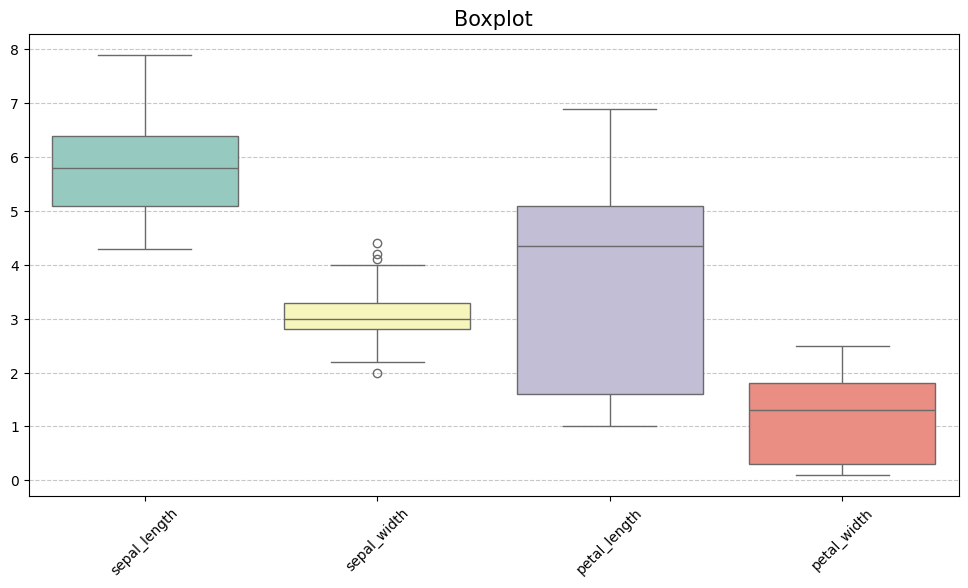

In [64]:
MAT.figure(figsize=(12, 6))
numeric_cols = Data_Iris.select_dtypes(include=[N.number]).columns
S.boxplot(data=Data_Iris[numeric_cols], palette='Set3')
MAT.title('Boxplot', fontsize=15)
MAT.xticks(rotation=45)
MAT.grid(axis='y', linestyle='--', alpha=0.7)
MAT.show()

In [65]:
Q1 = Data_Iris['sepal_width'].quantile(0.25)
Q3 = Data_Iris['sepal_width'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

no_outliers = Data_Iris[(Data_Iris['sepal_width'] >= lower) & (Data_Iris['sepal_width'] <= upper)]

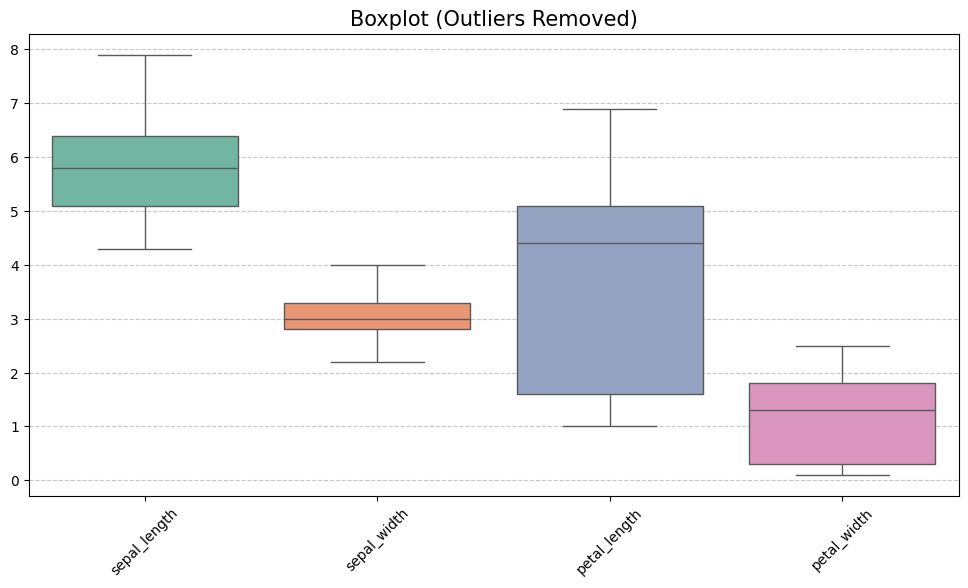

In [66]:
MAT.figure(figsize=(12, 6))
numeric_cols = no_outliers.select_dtypes(include=[N.number]).columns
S.boxplot(data=no_outliers[numeric_cols], palette='Set2')
MAT.title('Boxplot (Outliers Removed)', fontsize=15)
MAT.xticks(rotation=45)
MAT.grid(axis='y', linestyle='--', alpha=0.7)
MAT.show()

In [67]:
Data_Iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [68]:
scaler = MinMaxScaler()
Data_Iris[['sepal_length','sepal_width','petal_length','petal_width']] = scaler.fit_transform(Data_Iris[['sepal_length','sepal_width','petal_length','petal_width']])

In [69]:
LE = LabelEncoder()

Data_Iris['species'] = LE.fit_transform(Data_Iris['species'])

In [70]:
Data_Iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.111111,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0
...,...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667,2
146,0.555556,0.208333,0.677966,0.750000,2
147,0.611111,0.416667,0.711864,0.791667,2
148,0.527778,0.583333,0.745763,0.916667,2


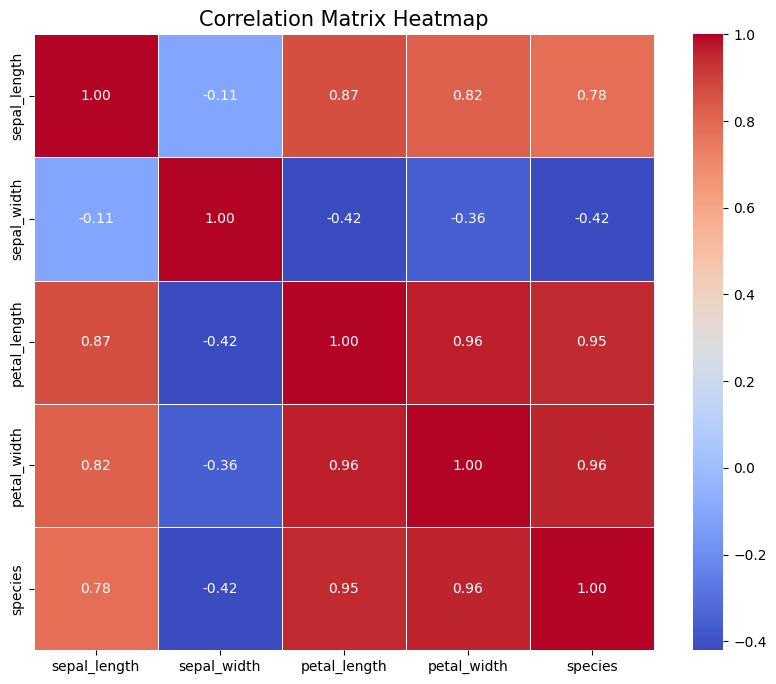

In [71]:
correlation_matrix = Data_Iris.corr()
MAT.figure(figsize=(10, 8))
S.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
MAT.title('Correlation Matrix Heatmap', fontsize=15)
MAT.show()

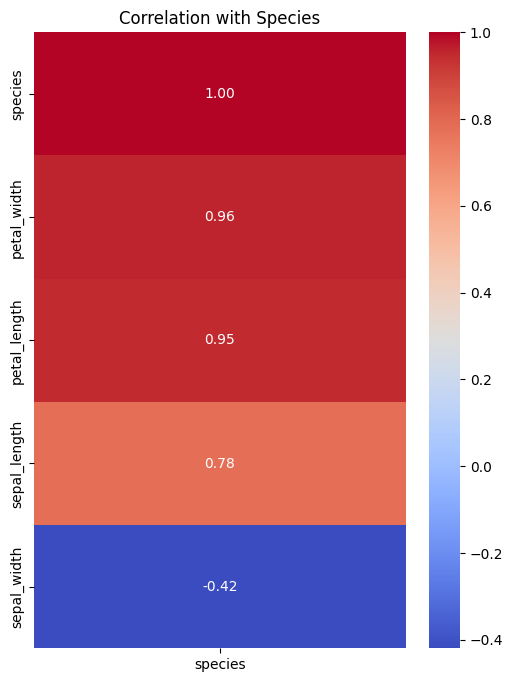

In [72]:
labeled = correlation_matrix[['species']].sort_values(by='species', ascending=False)

MAT.figure(figsize=(6, 8))
S.heatmap(labeled, annot=True, cmap='coolwarm', fmt='.2f')
MAT.title('Correlation with Species')
MAT.show()

In [73]:
TR, TD = train_test_split(Data_Iris, test_size=0.2, random_state=42)

In [74]:
y = TR['species']
X = TR.drop(['species', 'sepal_width'], axis=1)

In [75]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42)

In [76]:
X_T = TD.drop(['species', 'sepal_width'], axis=1)
Y_T = TD['species']

Y_hat = model.predict(X_T)

In [77]:
from sklearn.metrics import accuracy_score, classification_report

# Re-fit the model with the new feature set
model.fit(X, y)

# Generate new predictions
Y_hat = model.predict(X_T)

# Calculate and display new accuracy
accuracy = accuracy_score(Y_T, Y_hat)
print(f'New Accuracy Score (without sepal_width): {accuracy:.4%}')

print('\nClassification Report:')
print(classification_report(Y_T, Y_hat))

New Accuracy Score (without sepal_width): 100.0000%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



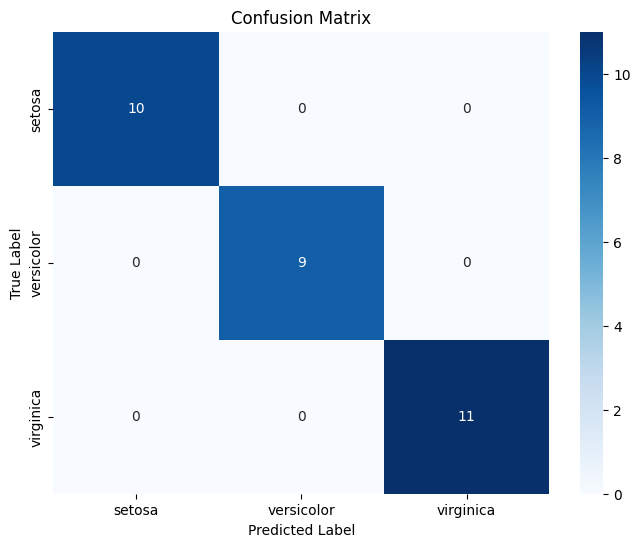

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as S
import matplotlib.pyplot as MAT

# Generate the confusion matrix
cm = confusion_matrix(Y_T, Y_hat)

# Plotting the confusion matrix
MAT.figure(figsize=(8, 6))
S.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=LE.classes_, yticklabels=LE.classes_)
MAT.xlabel('Predicted Label')
MAT.ylabel('True Label')
MAT.title('Confusion Matrix')
MAT.show()